# An IDAES flowsheet under drto

Every other example here declares its model by hand. This one takes a unit
model straight out of [IDAES](https://idaes-pse.readthedocs.io/) and drives it
with drto, to show that the declaration surface attaches to a flowsheet
somebody else built.

The plant is a CSTR running the saponification of ethyl acetate,
`NaOH + EthylAcetate -> SodiumAcetate + Ethanol`, from
`idaes.models.unit_models`. The reaction is exothermic, the jacket duty is the
manipulated variable, and the controlled variable is reactor temperature. The
reactor starts hot, at 318 K, and the controller has to bring it to the
304.04 K steady state the feed alone would settle at.

The whole example is two solves on one declared flowsheet: the model collapsed
to its setpoint, and the infinite-horizon controller.

Residence time is `V/F = 1 s`, so the horizon is three seconds at quarter-second
samples: three residence times, which is the timescale the loop actually lives
on.

In [1]:
%matplotlib inline
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import drto
import pyomo_pounce
from idaes.core import FlowsheetBlock
from idaes.models.unit_models import CSTR
from idaes.models.properties.examples.saponification_thermo import (
    SaponificationParameterBlock,
)
from idaes.models.properties.examples.saponification_reactions import (
    SaponificationReactionParameterBlock,
)
from idaes.core.util.model_statistics import degrees_of_freedom

F_IN, C_NAOH, C_EA = 1.0, 100.0, 100.0     # m3/s, mol/m3, mol/m3
T_IN, P_IN, VOLUME = 303.15, 101325.0, 1.0  # K, Pa, m3
T_START = 318.0                             # K, the perturbed start


def feed(blk, t):
    blk.inlet.flow_vol[t].fix(F_IN)
    blk.inlet.conc_mol_comp[t, "H2O"].fix(55388.0)
    blk.inlet.conc_mol_comp[t, "NaOH"].fix(C_NAOH)
    blk.inlet.conc_mol_comp[t, "EthylAcetate"].fix(C_EA)
    blk.inlet.conc_mol_comp[t, "SodiumAcetate"].fix(0.0)
    blk.inlet.conc_mol_comp[t, "Ethanol"].fix(0.0)
    blk.inlet.temperature[t].fix(T_IN)
    blk.inlet.pressure[t].fix(P_IN)


def cstr(m):
    m.fs.props = SaponificationParameterBlock()
    m.fs.rxn = SaponificationReactionParameterBlock(property_package=m.fs.props)
    m.fs.cstr = CSTR(property_package=m.fs.props, reaction_package=m.fs.rxn,
                     has_equilibrium_reactions=False, has_heat_of_reaction=True,
                     has_heat_transfer=True)
    return m

## Declaring the flowsheet

`drto.horizon` captures the set's points as the sample grid, so it has to be
called before discretization. That means the sample times go into
`FlowsheetBlock(time_set=...)` up front rather than being introduced by the
discretizer.

The rest maps one-to-one onto what IDAES already built. The states are the
holdups, whose `DerivativeVar`s are the accumulation terms; the dynamics are the
material and enthalpy balances; the control is `control_volume.heat`. Note the
control is declared on that Var and not on the unit-level `heat_duty`, which is
a Pyomo `Reference` to it: drto classifies on the referent, and declaring the
Reference leaves `heat` looking like an unexplained algebraic variable.

The targets are mutable Params, declared empty and filled from the steady
solve below: the declarations come first, and the numbers flow in afterward.

The starting point takes no solve. An initial condition only pins the
differential states, and this property package makes the energy holdup
closed-form: `V*dens_mol*cp_mol*(T - Tref)` with constant density and heat
capacity. The reactor starts at the setpoint composition but 14 K hot, and
the controller has to cool it back.

In [2]:
def build(nsample=12, dt=0.25, ncp=2):
    samples = [i * dt for i in range(nsample + 1)]
    m = pyo.ConcreteModel()
    m.fs = FlowsheetBlock(dynamic=True, time_set=samples, time_units=pyo.units.s)
    cstr(m)

    drto.horizon(m.fs.time)             # before discretization: it takes the grid
    pyo.TransformationFactory("dae.collocation").apply_to(
        m, wrt=m.fs.time, nfe=nsample, ncp=ncp, scheme="LAGRANGE-RADAU")
    for t in m.fs.time:
        feed(m.fs.cstr, t)
        m.fs.cstr.volume[t].fix(VOLUME)

    cv, t0 = m.fs.cstr.control_volume, m.fs.time.first()
    ms = list(cv.material_holdup.index_set().subsets())[1]
    es = list(cv.energy_holdup.index_set().subsets())[1]

    drto.state(cv.material_holdup, cv.energy_holdup)
    drto.dynamics(cv.material_balances, cv.enthalpy_balances)
    drto.control(cv.heat)

    U = pyo.units
    # targets and feedback Params declared in the owners' units, so the
    # registry reads back with the physics visible and the equations that
    # use them stay dimensionally consistent
    m.mat_ss = drto.steady_state(cv.material_holdup,
        pyo.Param(ms, initialize=0.0, mutable=True, units=U.mol))
    m.eng_ss = drto.steady_state(cv.energy_holdup,
        pyo.Param(es, initialize=0.0, mutable=True, units=U.J))
    m.duty_ss = drto.steady_state_control(cv.heat,
        pyo.Param(initialize=0.0, mutable=True, units=U.W))

    # the start is the setpoint composition perturbed hot; the energy
    # holdup is closed-form in T with this constant-property package
    props = m.fs.props
    e0 = VOLUME * pyo.value(
        props.dens_mol * props.cp_mol * (T_START * U.K - props.temperature_ref))
    m.mat0 = pyo.Param(ms, initialize=0.0, mutable=True, units=U.mol)
    m.eng0 = pyo.Param(es, initialize=e0, mutable=True, units=U.J)
    m.ic_mat = pyo.Constraint(ms, rule=lambda mm, p, c:
                              cv.material_holdup[t0, p, c] == mm.mat0[p, c])
    m.ic_eng = pyo.Constraint(es, rule=lambda mm, p:
                              cv.energy_holdup[t0, p] == mm.eng0[p])
    drto.initial_condition(m.ic_mat, m.ic_eng)

    # unit-carrying scales make the stage cost dimensionless, so it renders
    # with clean units instead of (inc): each term is (quantity/scale)**2
    m.scale_E = pyo.Param(initialize=1.0e6, units=U.J, mutable=True)
    m.scale_Q = pyo.Param(initialize=1.0e6, units=U.W, mutable=True)
    stages = samples[:-1]
    m.stage = pyo.Var(stages, initialize=0.0)
    m.stage_def = pyo.Constraint(stages, rule=lambda mm, t: mm.stage[t] == (
        ((cv.energy_holdup[t, "Liq"] - mm.eng_ss["Liq"]) / mm.scale_E) ** 2
        + ((cv.heat[t] - mm.duty_ss) / mm.scale_Q) ** 2))
    drto.tracking_stage_cost(m.stage_def)
    return m


m = build()
drto.info(m)

horizon,"fs._time (ContinuousSet, 25 points)"
states,"fs.cstr.control_volume.material_holdup (free, mol), fs.cstr.control_volume.energy_holdup (free, J)"
dynamics,"fs.cstr.control_volume.material_accumulation[t,p,j] == fs.cstr.control_volume.properties_in[t].flow_vol*fs.cstr.control_volume.properties_in[t].conc_mol_comp[j] - fs.cstr.control_volume.properties_out[t].flow_vol*fs.cstr.control_volume.properties_out[t].conc_mol_comp[j] + fs.cstr.control_volume.rate_reaction_generation[t,p,j] for t in fs.cstr.control_volume.SetProduct_OrderedSet (mol/s)"
dynamics,"fs.cstr.control_volume.energy_accumulation[t,Liq] == fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[t].flow_vol*(fs.cstr.control_volume.properties_in[t].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[t].flow_vol*(fs.cstr.control_volume.properties_out[t].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat[t] + (- fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[t,R1]) for t in fs._time (W)"
controls,"fs.cstr.control_volume.heat (piecewise_constant, free, W)"
tracking stage cost,"stage[t] == ((fs.cstr.control_volume.energy_holdup[t,'Liq'] - eng_ss[Liq])/scale_E)**2 + ((fs.cstr.control_volume.heat[t] - duty_ss)/scale_Q)**2 for t in sorted(fs._time)[:-1]"
initial conditions,"mat0[p,c] == fs.cstr.control_volume.material_holdup[0.0,p,c] for p in fs.props._phase_component_set, c in fs.props._phase_component_set (mol)"
initial conditions,"eng0[p] == fs.cstr.control_volume.energy_holdup[0.0,p] for p in fs.props.phase_list (J)"
steady-state targets,"mat_ss (of fs.cstr.control_volume.material_holdup, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)"
steady-state control targets,"duty_ss (of fs.cstr.control_volume.heat, W)"


## The setpoint from the declarations

The setpoint is where the feed alone drives the reactor, and the declared
model already contains that equilibrium. `drto.steady_state_simulation`
collapses the flowsheet to a single point and fixes the duty at zero: time
leaves the model, the accumulation terms are pinned, and the IDAES property
blocks collapse to their steady member alongside the flat holdups (feature
021). The steady target comes from the same physics the controller uses,
with no second flowsheet to build or keep in sync.

The solution fills the mutable Params: the tracking targets, and the start
composition for the perturbed-hot initial condition.

In [3]:
ss = pyo.TransformationFactory("drto.steady_state_simulation").create_using(
    m, controls={"fs.cstr.control_volume.heat": 0.0})
assert degrees_of_freedom(ss) == 0
pyo.SolverFactory("pounce").solve(ss, tee=True)

cvs = ss.fs.cstr.control_volume
print(f"setpoint  T = {pyo.value(cvs.properties_out[0.0].temperature):7.3f} K"
      f"   NaOH = {pyo.value(cvs.properties_out[0.0].conc_mol_comp['NaOH']):6.3f} mol/m3")

for k in m.mat_ss:
    m.mat_ss[k] = m.mat0[k] = pyo.value(cvs.material_holdup[k])
for k in m.eng_ss:
    m.eng_ss[k] = pyo.value(cvs.energy_holdup[k])
drto.info(ss)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpp150spnj.pyomo.nl...
pounce: wrote C:\

Parsed 22 vars, 22 cons, jac_nnz=49, h_nnz=10 in 0.00s
Problem class: NLP. Selected solver: NLP filter line-search interior-point (pounce-nlp) [solver_selection=auto].

Number of nonzeros in equality constraint Jacobian...:       49
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       10

Total number of variables............................:       22
                     variables with only lower bounds:        6
                variables with lower and upper bounds:        2
                     variables with only upper bounds:        0
Total number of equality constraints.................:       22
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) 

setpoint  T = 304.039 K   NaOH = 24.286 mol/m3


states,"fs.cstr.control_volume.material_holdup (free), fs.cstr.control_volume.energy_holdup (free)"
dynamics,"fs.cstr.control_volume.material_accumulation[o,_r] == fs.cstr.control_volume.properties_in[0.0].flow_vol*fs.cstr.control_volume.properties_in[0.0].conc_mol_comp[_r] - fs.cstr.control_volume.properties_out[0.0].flow_vol*fs.cstr.control_volume.properties_out[0.0].conc_mol_comp[_r] + fs.cstr.control_volume.rate_reaction_generation[o,_r] for o in fs.props._phase_component_set (inc)"
dynamics,fs.cstr.control_volume.energy_accumulation[Liq] == fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[0.0].flow_vol*(fs.cstr.control_volume.properties_in[0.0].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[0.0].flow_vol*(fs.cstr.control_volume.properties_out[0.0].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat - fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[R1] (inc)
controls,fs.cstr.control_volume.heat (fixed)
steady-state targets,"mat_ss (of fs.cstr.control_volume.material_holdup, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)"
steady-state control targets,"duty_ss (of fs.cstr.control_volume.heat, W)"


## The infinite-horizon controller

`drto.infinite_horizon` appends the terminal segment (feature 020): the IDAES
property blocks replicate onto the tail as algebraic families, and the feeds
carry onto it with no declaration involved. They are fixed variables, and
fixed means fixed: each one's segment copy is fixed at its horizon-end value.
(They are not disturbances: drto's disturbances are zero-mean noise, which
the optimization mode fixes at zero on the horizon.)

`drto.dynamic_optimization` then frees the controls, applies the declared
profiles and assembles the objective, so the declared model becomes the
solvable controller in two transformation calls.

In [4]:
pyo.TransformationFactory("drto.infinite_horizon").apply_to(m)
pyo.TransformationFactory("drto.dynamic_optimization").apply_to(m)
print("degrees of freedom:", degrees_of_freedom(m))
res = pyo.SolverFactory("pounce").solve(m, tee=True)
print("termination:", res.solver.termination_condition)

degrees of freedom: 33


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpduzhybl0.pyomo.nl...
Parsed 1195 vars,

   8  1.4784756e+05 8.26e+07 9.61e+04   -1.0 9.56e+08      - 1.87e-03 1.31e-03h  1
   9  1.4859709e+05 8.23e+07 3.80e+05   -1.0 9.16e+08      - 4.62e-03 3.37e-03h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  10  1.5124713e+05 8.13e+07 9.25e+05   -1.0 8.92e+08      - 7.95e-03 1.17e-02h  1
  11  1.5175849e+05 8.11e+07 9.17e+05   -1.0 8.40e+08      - 2.18e-02 2.63e-03h  1
  12  1.5429176e+05 8.00e+07 7.66e+05   -1.0 8.13e+08      - 3.45e-02 1.37e-02h  1
  13  1.5712991e+05 7.86e+07 6.95e+05   -1.0 7.57e+08      - 6.93e-02 1.71e-02h  1
  14  1.5978959e+05 7.73e+07 6.61e+05   -1.0 7.12e+08      - 1.02e-01 1.75e-02h  1
  15  1.6081756e+05 7.67e+07 6.54e+05   -1.0 6.72e+08      - 2.17e-01 7.25e-03h  1
  16  1.8813422e+05 6.31e+07 3.79e+05   -1.0 6.57e+08      - 2.08e-01 1.78e-01h  1
  17  2.2604629e+05 4.76e+07 3.27e+05   -1.0 3.17e+08      - 3.74e-01 2.45e-01h  1
  18  3.0285465e+05 2.14e+07 1.24e+05   -1.0 1.47e+08      - 3.36e-01 5.50e-01h  1
  19

  59  7.5415798e+03 4.84e-07 2.42e+00   -8.6 2.39e-05   -6.1 1.00e+00 1.95e-03h 10
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  60  7.5415798e+03 4.84e-07 2.43e+00   -8.6 5.30e-05   -6.6 1.00e+00 2.44e-04h 13
  61  7.5415798e+03 2.05e-07 2.59e-11   -8.6 5.52e-05   -5.3 1.00e+00 1.00e+00h  1
  62  7.5415798e+03 2.05e-07 2.42e+00   -8.6 1.64e-05   -5.7 1.00e+00 3.91e-03h  9
  63  7.5415798e+03 2.78e-07 2.99e-11   -8.6 1.64e-05   -6.2 1.00e+00 1.00e+00s  1
  64  7.5415798e+03 2.51e-07 3.38e-11   -8.6 3.11e-05   -5.8 1.00e+00 1.00e+00s  1
  65r 7.5415798e+02 2.51e-07 9.99e+02   -6.6 0.00e+00   -6.3 0.00e+00 0.00e+00R  0
  66r 7.5415798e+02 3.35e-07 2.22e+01   -6.6 2.51e-04   -2.0 9.78e-01 9.90e-04f  1
  67r 7.5415800e+02 3.89e-07 8.95e+02   -6.6 3.90e-05   -2.5 1.32e-03 1.98e-01f  1
  68r 7.5415815e+02 4.72e-07 6.66e+01   -6.6 1.82e+01      - 2.31e-01 9.73e-01h  1
  69r 7.5415833e+02 6.92e-07 5.86e+00   -6.6 2.34e+07      - 7.45e-01 1.00e+00h  1
iter

  94  7.5415798e+03 1.42e-07 1.21e+00   -8.6 7.48e+02  -11.5 1.00e+00 5.00e-01h  2
  95  7.5415798e+03 7.86e-07 1.17e-04   -8.6 3.60e+03  -12.0 1.00e+00 1.00e+00s  1
  96  7.5415798e+03 3.00e-07 6.85e-05   -8.6 1.24e+03  -12.5 1.00e+00 1.00e+00s  1
  97  7.5415798e+03 2.38e-07 3.01e-05   -8.6 5.48e+02  -12.9 1.00e+00 1.00e+00s  1
  98  7.5415798e+03 5.31e-07 3.66e-05   -8.6 3.79e+03  -13.4 1.00e+00 1.00e+00s  1
  99  7.5415798e+03 3.28e-07 3.65e-08   -8.6 8.34e+02  -13.9 1.00e+00 1.00e+00s  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
 100r 7.5415798e+02 3.28e-07 9.99e+02   -6.5 0.00e+00  -14.4 0.00e+00 0.00e+00R  0
 101r 7.5415798e+02 2.07e-07 7.30e+02   -6.5 2.68e+07      - 2.69e-01 9.90e-04f  1
 101  7.5415798e+03 2.07e-07 3.53e+01   -8.6 2.52e+02  -14.4 0.00e+00 0.00e+00R  0
 102  7.5415798e+03 3.23e-05 2.18e-03   -8.6 5.69e+03  -14.9 1.00e+00 1.00e+00h  1
 103  7.5415797e+03 3.15e-05 4.73e-08   -8.6 5.61e+03  -15.3 1.00e+00 1.00e+00h  1
 104

...

 209r 7.5415945e+02 1.12e-02 1.78e+01   -6.7 1.28e+13      - 3.87e-01 9.76e-01H  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
 210r 7.5415835e+02 1.25e-06 3.95e+00   -6.7 4.98e+05      - 6.81e-01 1.00e+00h  1
 211r 7.5415899e+02 1.86e-07 1.73e+00   -6.7 6.43e-01      - 5.62e-01 1.00e+00h  1
 211  7.5415899e+03 1.86e-07 1.00e+02   -8.6 7.24e-01  -20.0 0.00e+00 0.00e+00R  0
 212  7.5415616e+03 1.50e+02 8.62e+01   -8.6 8.87e+07  -18.2 1.00e+00 1.38e-01f  1
 213  5.2004367e+03 7.85e+03 7.03e+01   -8.6 8.87e+07  -18.7 7.39e-01 9.99e-01f  1
 214  7.7083453e+02 5.84e+03 3.32e-02   -8.6 7.64e+07  -19.1 1.00e+00 1.00e+00f  1
 215  7.3081143e+03 2.01e+02 1.15e-03   -8.6 8.11e+04  -19.6 1.00e+00 9.66e-01h  1
 216  7.4248470e+03 1.01e+02 7.31e+00   -8.6 2.75e+03  -20.0 1.00e+00 5.00e-01h  2
 217  7.4832134e+03 5.04e+01 1.94e+00   -8.6 1.38e+03  -20.0 1.00e+00 5.00e-01h  2
 218  7.5402697e+03 1.13e+00 5.28e-02   -8.6 6.89e+02  -20.0 1.00e+00 9.78e-01h  1
 219

pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmpduzhybl0.pyomo.sol


 242  7.5415798e+03 5.82e-07 3.96e-14   -8.6 7.24e-01  -20.0 1.00e+00 1.00e+00h  1


Number of Iterations....: 242

                                   (scaled)                 (unscaled)
Objective...............:   7.5415797534776311e+02    7.5415797534776311e+03
Dual infeasibility......:   3.9573843245610061e-14    3.9573843245610061e-13
Constraint violation....:   5.8207660913467407e-07    4.8838555812835685e-06
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059035596800754e-09    2.5059035596800754e-08
Overall NLP error.......:   5.8207660913467407e-07    4.8838555812835685e-06


Number of objective function evaluations             = 1079
Number of objective gradient evaluations             = 213
Number of equality constraint evaluations            = 1096
Number of inequality constraint evaluations          = 1096
Number of equality constraint Jacobian evaluations   = 259
Number of inequality constraint Jacobian evaluation

model.name="unknown";
    - termination condition: optimal
    - message from solver: POUNCE 0.9.0\x3a SolvedToAcceptableLevel


termination: optimal


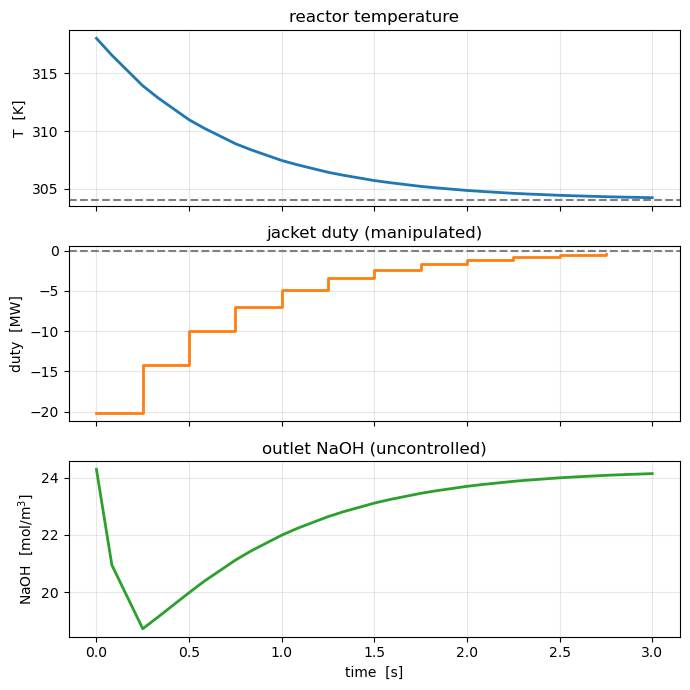

In [5]:
cv = m.fs.cstr.control_volume
t_all = sorted(m.fs.time)
T = [pyo.value(cv.properties_out[t].temperature) for t in t_all]
naoh = [pyo.value(cv.properties_out[t].conc_mol_comp["NaOH"]) for t in t_all]
samples = sorted(m.stage.index_set())
duty = [pyo.value(cv.heat[t]) / 1e6 for t in samples]
T_sp = pyo.value(cvs.properties_out[0.0].temperature)

fig, ax = plt.subplots(3, 1, figsize=(7, 7), sharex=True)
ax[0].plot(t_all, T, lw=2)
ax[0].axhline(T_sp, ls="--", c="0.5")
ax[0].set_ylabel("T  [K]"); ax[0].set_title("reactor temperature")
ax[1].step(samples, duty, where="post", lw=2, c="C1")
ax[1].axhline(0.0, ls="--", c="0.5")
ax[1].set_ylabel("duty  [MW]"); ax[1].set_title("jacket duty (manipulated)")
ax[2].plot(t_all, naoh, lw=2, c="C2")
ax[2].set_ylabel("NaOH  [mol/m$^3$]"); ax[2].set_xlabel("time  [s]")
ax[2].set_title("outlet NaOH (uncontrolled)")
for a in ax: a.grid(alpha=0.3)
fig.tight_layout()
plt.show()


In [6]:
seg = m.drto_ih
print(f"first duty move : {pyo.value(cv.heat[0.0]):,.0f} W")
print(f"tail endpoint   : E = {pyo.value(seg.energy_holdup['Liq', 1]):,.0f} J"
      f"   (setpoint {pyo.value(m.eng_ss['Liq']):,.0f} J)")
print(f"tail feed       : F = {pyo.value(seg.properties_in_flow_vol[1]):.2f} m3/s, fixed="
      f"{seg.properties_in_flow_vol[1].fixed}")
drto.info(m)

first duty move : -20,200,663 W
tail endpoint   : E = 24,571,048 J   (setpoint 24,571,048 J)
tail feed       : F = 1.00 m3/s, fixed=True


horizon,"fs._time (ContinuousSet, 25 points)"
states,"fs.cstr.control_volume.material_holdup (free, mol), fs.cstr.control_volume.energy_holdup (free, J)"
dynamics,"fs.cstr.control_volume.material_accumulation[t,p,j] == fs.cstr.control_volume.properties_in[t].flow_vol*fs.cstr.control_volume.properties_in[t].conc_mol_comp[j] - fs.cstr.control_volume.properties_out[t].flow_vol*fs.cstr.control_volume.properties_out[t].conc_mol_comp[j] + fs.cstr.control_volume.rate_reaction_generation[t,p,j] for t in fs.cstr.control_volume.SetProduct_OrderedSet (mol/s)"
dynamics,"fs.cstr.control_volume.energy_accumulation[t,Liq] == fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[t].flow_vol*(fs.cstr.control_volume.properties_in[t].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[t].flow_vol*(fs.cstr.control_volume.properties_out[t].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat[0.0] - fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[t,R1] for t in fs._time (W)"
controls,"fs.cstr.control_volume.heat (piecewise_constant, free, W)"
tracking stage cost,"stage[t] == ((fs.cstr.control_volume.energy_holdup[t,'Liq'] - eng_ss[Liq])/scale_E)**2 + ((fs.cstr.control_volume.heat[t] - duty_ss)/scale_Q)**2 for t in sorted(fs._time)[:-1]"
initial conditions,"mat0[p,c] == fs.cstr.control_volume.material_holdup[0.0,p,c] for p in fs.props._phase_component_set, c in fs.props._phase_component_set (mol)"
initial conditions,"eng0[p] == fs.cstr.control_volume.energy_holdup[0.0,p] for p in fs.props.phase_list (J)"
steady-state targets,"mat_ss (of fs.cstr.control_volume.material_holdup, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)"
steady-state control targets,"duty_ss (of fs.cstr.control_volume.heat, W)"
cost_group,"drto_ih, drto_ih"


The two registries tell the whole story between them. The steady model's log
records the property blocks collapsed to their steady member for the
setpoint; the controller's log records the same blocks replicated onto the
terminal segment, the copies built with their sources' units so the
replicated balances stay dimensionally consistent on the tail.